# Spotify Data Analysis

**Author:** Alyssa Leuschner \
**Timeframe:** March 2020 - July 2026 (~ 6.5 Years) \
**Topic:** Analysis of my listening habits \
**Project No.:** 1

In [804]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Data Exploration & Cleaning 

In [805]:
# Load individual JSON streaming history files

df_2020 = pd.read_json("data/Streaming_History_Audio_2020.json")
df_2021 = pd.read_json("data/Streaming_History_Audio_2021.json")
df_2022_1 = pd.read_json("data/Streaming_History_Audio_2022_1_0101_1907.json")
df_2022_2 = pd.read_json("data/Streaming_History_Audio_2022_2_1907_3112.json")
df_2023_1 = pd.read_json("data/Streaming_History_Audio_2023_1_0101_2704.json")
df_2023_2 = pd.read_json("data/Streaming_History_Audio_2023_2_2704_0708.json")
df_2023_3 = pd.read_json("data/Streaming_History_Audio_2023_3_0708_3112.json")
df_2024_1 = pd.read_json("data/Streaming_History_Audio_2024_1_0101_2005.json")
df_2024_2 = pd.read_json("data/Streaming_History_Audio_2024_2_2005_0111.json")
df_2024_3 = pd.read_json("data/Streaming_History_Audio_2024_3_0111_3112.json")
df_2025_1 = pd.read_json("data/Streaming_History_Audio_2025_1_0101_2305.json")
df_2025_2 = pd.read_json("data/Streaming_History_Audio_2025_2_2305_1509.json")
df_2025_3 = pd.read_json("data/Streaming_History_Audio_2025_3_1509_0512.json")
df_2025_4 = pd.read_json("data/Streaming_History_Audio_2025_4_0512_3112.json")
df_2026_1 = pd.read_json("data/Streaming_History_Audio_2026_1_0101_0207.json")
df_2026_2 = pd.read_json("data/Streaming_History_Audio_2026_2_0207_2507.json")

In [806]:
# Merging individual yearly files into one data set

complete_data = pd.concat(
    [df_2020,
    df_2021, 
    df_2022_1, df_2022_2, 
    df_2023_1, df_2023_2, df_2023_3,
    df_2024_1, df_2024_2, df_2023_3,
    df_2025_1, df_2025_2, df_2025_3, df_2025_4,
    df_2026_1, df_2026_2],
    axis= 0, join= "inner", ignore_index= True)

In [807]:
complete_data.columns

Index(['ts', 'platform', 'ms_played', 'conn_country', 'ip_addr',
       'master_metadata_track_name', 'master_metadata_album_artist_name',
       'master_metadata_album_album_name', 'spotify_track_uri', 'episode_name',
       'episode_show_name', 'spotify_episode_uri', 'audiobook_title',
       'audiobook_uri', 'audiobook_chapter_uri', 'audiobook_chapter_title',
       'reason_start', 'reason_end', 'shuffle', 'skipped', 'offline',
       'offline_timestamp', 'incognito_mode'],
      dtype='str')

In [808]:
# Removing sensitive and irrelevant data (focus on music only)

cleaned_data = complete_data.drop(columns= [
    "ip_addr",
    "conn_country",
    "spotify_track_uri",
    "episode_name",
    "episode_show_name",
    "spotify_episode_uri",
    "audiobook_title",
    "audiobook_uri",
    "audiobook_chapter_uri",
    "audiobook_chapter_title",
    "offline_timestamp",
    "incognito_mode"
])

In [809]:
# Rename certain columns

cleaned_data = cleaned_data.rename(columns={
    "master_metadata_track_name": "track",
    "master_metadata_album_artist_name": "artist",
    "master_metadata_album_album_name": "album"
})

In [810]:
cleaned_data["ts"] = pd.to_datetime(cleaned_data["ts"])

In [811]:
# Looking for missing values

cleaned_data.isna().sum()

ts                0
platform          0
ms_played         0
track           122
artist          122
album           122
reason_start      0
reason_end        0
shuffle           0
skipped           0
offline           0
dtype: int64

In [812]:
# Drop rows where metadata is missing, due to delisted songs

cleaned_data = cleaned_data.dropna(
    subset= [
        "track",
        "artist",
        "album"],
    axis= 0).copy()

In [813]:
# Creating a new column, to filter streams shorter than 30 seconds

cleaned_data["minutes_played"] = (cleaned_data["ms_played"]/ 60000).round(2)
cleaned_data = cleaned_data[cleaned_data["ms_played"] >= 30000].copy()

In [814]:
# Creating a new column, to extract the year

cleaned_data["year"] = cleaned_data["ts"].dt.year

In [815]:
# Check for duplicates

cleaned_data.duplicated().sum()

np.int64(6444)

In [816]:
# Remove duplicates

cleaned_data = cleaned_data.drop_duplicates()
cleaned_data.duplicated().sum()

np.int64(0)

### Exploratory Data Analysis

#### Q1: Which device do I use to listen to music?

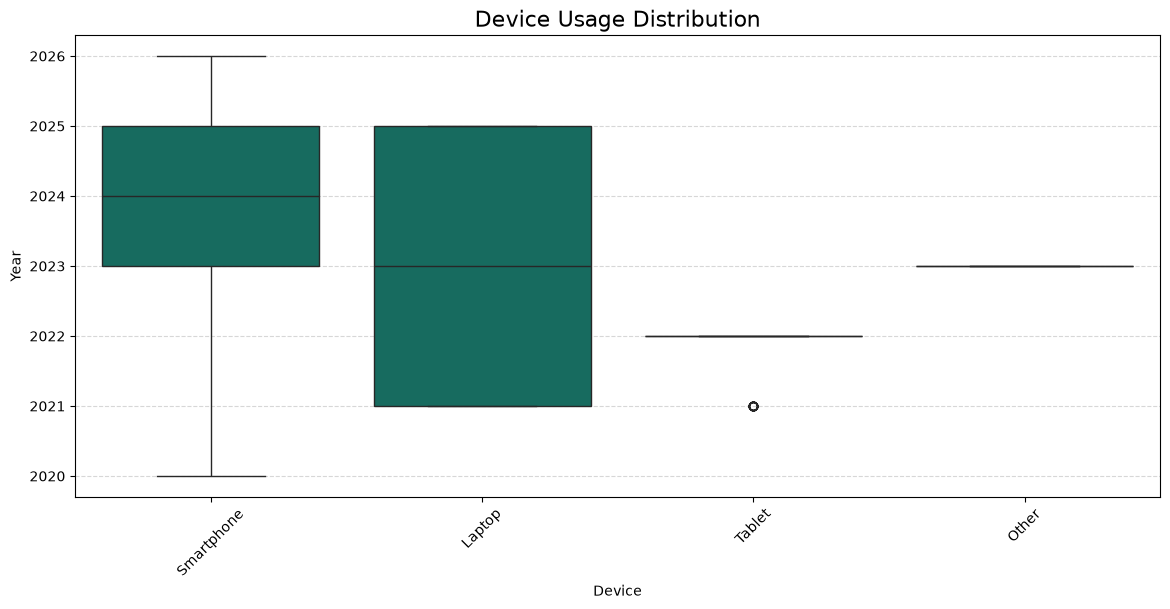

In [817]:
# Define function to simplify the device names

def device(name):

    if "iPhone" in name or "ios" in name:
        return "Smartphone"
    elif "iPad" in name:
        return "Tablet"
    elif "web_player" in name or "osx" in name:
        return "Laptop"
    else:
        return "Other"  


# Creating a new column for devices

cleaned_data["device"] = cleaned_data["platform"].apply(device)


# Creating a boxplot

plt.figure(figsize=(14, 6))
sns.boxplot(data= cleaned_data, x= "device", y= "year", color= "#097969")

plt.title("Device Usage Distribution", fontsize= "16")
plt.xlabel("Device")
plt.xticks(rotation=45)
plt.ylabel("Year")

plt.grid(axis= "y", linestyle= "--", alpha= 0.5)

plt.show()


In [818]:
cleaned_data["device"].value_counts()

device
Smartphone    85178
Laptop         3448
Tablet          690
Other            34
Name: count, dtype: int64

#### Q2: How has my listening volume developed in the past 7.5 years?

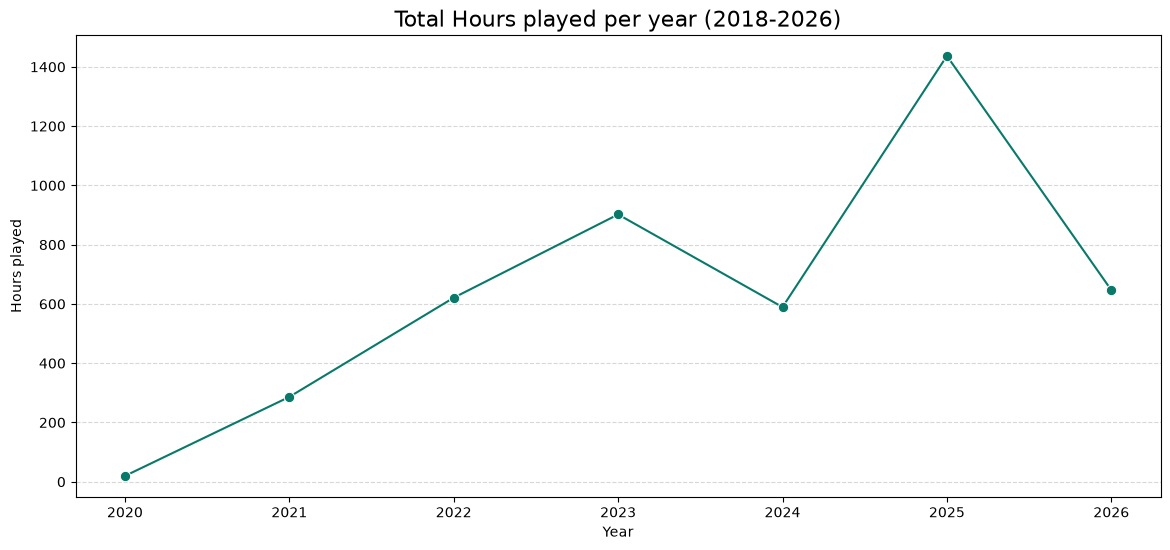

In [819]:
#
yearly_hours = cleaned_data.groupby("year", as_index= False)["minutes_played"].sum()
yearly_hours["hours_played"] = yearly_hours["minutes_played"]/ 60


# Creating a linechart

plt.figure(figsize=(14,6))
sns.lineplot(data= yearly_hours, x= "year", y= "hours_played", color= "#097969", marker= "o", markersize= "7.5", linewidth= "1.5")

plt.title("Total Hours played per year (2018-2026)", fontsize= "16")
plt.xlabel("Year")
plt.ylabel("Hours played")

plt.grid(axis= "y", linestyle= "--", alpha= 0.5)

plt.show()

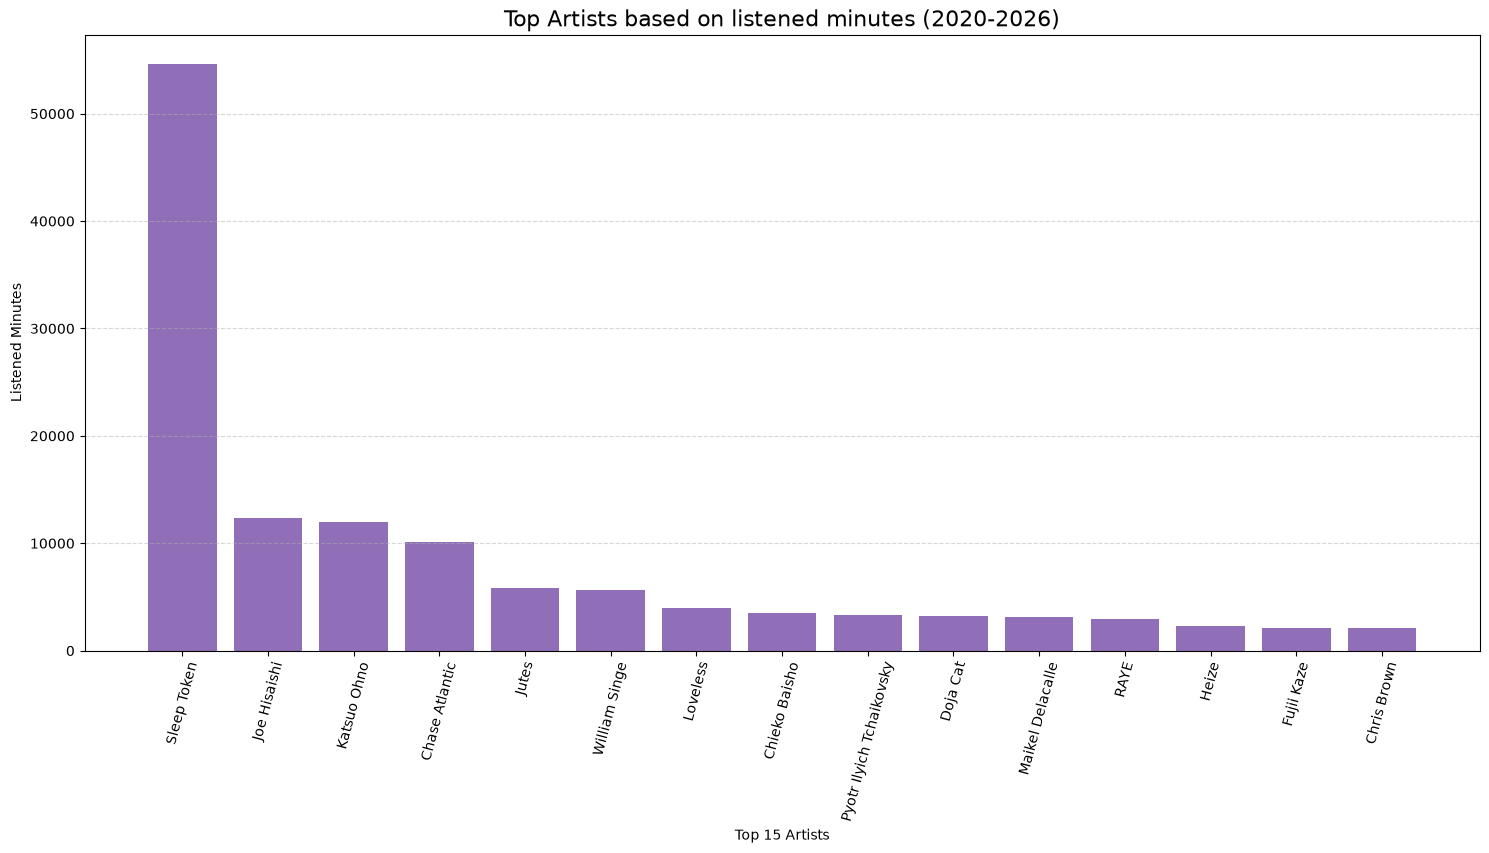

In [820]:
#
top_artists = (cleaned_data.groupby("artist")["minutes_played"].sum().sort_values(ascending= False).head(15))

# 
plt.figure(figsize=(18,8))

plt.bar(x= top_artists.index, height= top_artists.values, color= "#6B3FA0", alpha= 0.75, width= 0.8)

plt.title("Top Artists based on listened minutes (2020-2026)", fontsize= "16")
plt.xlabel("Top 15 Artists")
plt.xticks(rotation= 75)
plt.ylabel("Listened Minutes")

plt.grid(axis= "y", linestyle= "--", alpha= 0.5)
plt.show()

#### Q3: Do major life events (e.g. moving to Vienna, switching majors from Humanities to Data Science) correlate with changes in listening habits and if yes, how?

#### Q4: How has my music taste shifted?

In [821]:
# Define seven selected artists and the first time they were listened to (with timestamps)

ft_sleep_token = cleaned_data[cleaned_data["artist"] == "Sleep Token"]["ts"].min()
ft_jutes = cleaned_data[cleaned_data["artist"] == "Jutes"]["ts"].min()
ft_singe = cleaned_data[cleaned_data["artist"] == "William Singe"]["ts"].min()
ft_tchaikovsky = cleaned_data[cleaned_data["artist"] == "Pyotr Ilyich Tchaikovsky"]["ts"].min()
ft_delacalle = cleaned_data[cleaned_data["artist"] == "Maikel Delacalle"]["ts"].min()
ft_loveless = cleaned_data[cleaned_data["artist"] == "Loveless"]["ts"].min()
ft_heize = cleaned_data[cleaned_data["artist"] == "Heize"]["ts"].min()

In [822]:
# Create a dictionary which combines artist and the first time they were listened to

artist_data = {
    'Artist': ["Sleep Token", "Jutes", "William Singe", "Pyotr Ilyitch Tchaikovsky", "Maikel Delacalle", "Loveless", "Heize"],
    'First listened on': [ft_sleep_token, ft_jutes, ft_singe, ft_tchaikovsky, ft_delacalle, ft_loveless, ft_heize]
}

# Creata a data frame

pd.DataFrame(artist_data).sort_values(by= "Artist").reset_index(drop= True)

,Artist,First listened on
0,Heize,2025-01-01 16:32:27+00:00
1,Jutes,2024-07-20 12:00:27+00:00
2,Loveless,2022-06-10 21:44:07+00:00
3,Maikel Delacalle,2021-01-01 13:51:52+00:00
4,Pyotr Ilyitch Tchaikovsky,2021-12-20 18:49:05+00:00
5,Sleep Token,2023-06-18 20:49:08+00:00
6,William Singe,2020-11-05 11:31:30+00:00


#### Q5: Are there seasonal genre patterns throughout the year? (months + week)

#### Q6: Can study sessions be identified in the data (e.g. songs on repeat, specific artist I like to listen to while studying)?